# 04 · Reshape and transpose real images

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/project-delphi/tensors-workshop/blob/main/notebooks/04-reshape-and-transpose.ipynb)

*Part III · exercise · 15 min*

> 🇪🇸 **Reshape y transposición de imágenes reales** — Reordenar ejes correctamente en imágenes y lotes reales, y comprobar por qué `reshape` puede conservar la forma mientras destruye el significado.

Use real images to move between HWC↔CHW and NHWC↔NCHW, then show why matching shapes do not guarantee matching axis semantics.

## What you will be able to do

- Convert a real RGB image between `(H, W, C)` and `(C, H, W)` with `np.transpose`.
- Build a batch from three distinct real RGB images and convert NHWC to NCHW.
- Explain why two axes with the same size cannot be identified from shape alone.
- Demonstrate on a real image why `reshape` can run without error and still scramble the data.

## Setup

Run this first. It loads real microscopy, histology, and photographic image data used throughout the notebook.

> 🇪🇸 Ejecuta esta celda primero. Carga datos reales de microscopía, histología y fotografía que se usarán en toda la sección.

In [1]:
import numpy as np
from skimage import data

# Real images distributed with scikit-image.
photo = data.immunohistochemistry()   # (512, 512, 3) real histology, RGB
cells = data.cell()                   # (660, 550)    real microscopy, grayscale
astronaut = data.astronaut()          # (512, 512, 3) real RGB photograph
coffee = data.coffee()                # (400, 600, 3) real RGB photograph


def center_crop_rgb(img, size=256):
    """Take a deterministic centre crop so distinct real RGB images can be stacked."""
    h, w, c = img.shape
    if c != 3 or h < size or w < size:
        raise ValueError(f"expected RGB image at least {size}x{size}, got {img.shape}")
    r0 = (h - size) // 2
    c0 = (w - size) // 2
    return img[r0:r0 + size, c0:c0 + size]


rgb_sources = [photo, astronaut, coffee]

print("histology:", photo.shape)
print("microscopy:", cells.shape)
print("astronaut:", astronaut.shape)
print("coffee:", coffee.shape)

histology: (512, 512, 3)
microscopy: (660, 550)
astronaut: (512, 512, 3)
coffee: (400, 600, 3)


## Why this matters

Image-acquisition software and ML frameworks can use different axis conventions. A tensor may contain the right numbers and still be interpreted incorrectly if height, width, colour, or batch axes are in the wrong positions.

That is especially dangerous because many axis mistakes do **not** raise an error. The code can keep running on data whose semantics have been scrambled.

A familiar engineering example is moving image batches between TensorFlow-style `NHWC` and PyTorch-style `NCHW` conventions.

> 🇪🇸 **Por qué importa:** distintos sistemas de adquisición y frameworks pueden usar convenciones diferentes para los ejes. Un tensor puede contener los números correctos y aun así interpretarse mal si lote, alto, ancho o color están en posiciones incorrectas. Muchos de estos errores no generan una excepción: el código sigue funcionando con datos semánticamente desordenados.

### Predict → Run → Explain

Before each exercise, predict the output shape **and name what every axis means**. After running, explain why the operation preserved or destroyed that meaning.

> 🇪🇸 **Predice → Ejecuta → Explica:** antes de cada ejercicio, predice la forma de salida y nombra el significado de cada eje. Después explica por qué la operación conservó o destruyó ese significado.

## Exercise 1 — one real image, two orderings

**Predict first:** `photo` is a real RGB histology image and `cells` is a real grayscale microscopy image. Which one has a colour axis? What should the shape of `photo` become after HWC → CHW?

> 🇪🇸 **Predice primero:** `photo` es una imagen histológica RGB real y `cells` es una imagen microscópica real en escala de grises. ¿Cuál tiene eje de color? ¿Qué forma debe tener `photo` después de HWC → CHW?

In [2]:
# TODO 1: Print both shapes. Which one has no colour axis?
#
# TODO 2: Convert `photo` from (H, W, C) to (C, H, W) with np.transpose.
#         Name what each output axis represents.


In [3]:
#@title Solution — try it yourself first { display-mode: 'form' }
print(photo.shape, cells.shape)   # (512, 512, 3) (660, 550)
# `cells` is grayscale — order 2, no colour axis at all.

chw = np.transpose(photo, (2, 0, 1))      # (3, 512, 512) — correct
print(chw.shape)

# The tuple (2, 0, 1) means:
# new axis 0 <- old axis 2 (colour)
# new axis 1 <- old axis 0 (height)
# new axis 2 <- old axis 1 (width)
assert np.array_equal(chw, np.moveaxis(photo, 2, 0))


(512, 512, 3) (660, 550)
(3, 512, 512)


## Exercise 2 — a real batch, and two axes of the same size

Instead of stacking three copies of one image, build a batch from **three distinct real RGB images**: histology, astronaut, and coffee. A deterministic centre crop makes them the same spatial size without inventing pixel values.

**Predict first:** after stacking, the batch will be `(N, H, W, C) = (3, 256, 256, 3)`. After NHWC → NCHW it will be `(3, 3, 256, 256)`. Which size-3 axis is batch, and which is colour?

> 🇪🇸 Construye el lote con **tres imágenes RGB reales distintas**. El recorte central solo selecciona píxeles medidos; no inventa valores. Predice qué eje de tamaño 3 representa el lote y cuál representa el color después de NHWC → NCHW.

In [4]:
# TODO 3:
# Centre-crop each image in `rgb_sources` to 256x256 with center_crop_rgb(...)
# and stack them into a REAL batch of shape (3, 256, 256, 3).
# Which axis is the batch axis?
#
# TODO 4:
# Convert that batch from NHWC to NCHW -> (3, 3, 256, 256).
# Two axes now both have size 3. Demonstrate with indexing what axis 0 means
# and what axis 1 means. Do not infer semantics from size alone.


In [5]:
#@title Solution — try it yourself first { display-mode: 'form' }

batch = np.stack([center_crop_rgb(img) for img in rgb_sources])
print("NHWC:", batch.shape)                      # (3, 256, 256, 3)

nchw = np.transpose(batch, (0, 3, 1, 2))
print("NCHW:", nchw.shape)                       # (3, 3, 256, 256)

# Same numerical shape after fixing one of the two size-3 axes,
# but completely different semantics:
one_image = nchw[0]                              # (C, H, W)
red_channel_all_images = nchw[:, 0]              # (N, H, W)

print("nchw[0]   :", one_image.shape, "-> one image, all 3 colour channels")
print("nchw[:, 0]:", red_channel_all_images.shape, "-> red channel, all 3 images")

# Verify those semantics against the original NHWC representation.
assert np.array_equal(one_image, np.transpose(batch[0], (2, 0, 1)))
assert np.array_equal(red_channel_all_images, batch[:, :, :, 0])


NHWC: (3, 256, 256, 3)
NCHW: (3, 3, 256, 256)
nchw[0]   : (3, 256, 256) -> one image, all 3 colour channels
nchw[:, 0]: (3, 256, 256) -> red channel, all 3 images


## Exercise 3 — the operation that runs and is still wrong

`photo` is real RGB data with shape `(512, 512, 3)`. Both `transpose` and `reshape` can produce an array with shape `(3, 512, 512)`, but only one operation moves the colour axis correctly.

**Predict first:** will equal output shapes imply equal pixel organization?

> 🇪🇸 `photo` contiene datos RGB reales. Tanto `transpose` como `reshape` pueden producir `(3, 512, 512)`, pero solo una operación reordena correctamente el eje de color. **Predice primero:** ¿tener la misma forma implica conservar la misma organización de los píxeles?

In [6]:
# TODO 5:
# Run photo.reshape(3, 512, 512). It succeeds without an error.
# Compare it with the correct CHW tensor from np.transpose(photo, (2, 0, 1)).
# Verify whether the arrays are equal, then display the first plane from both.
# Explain why reshape cannot replace transpose when axis meaning must change.


same shape: True
same data arrangement: False


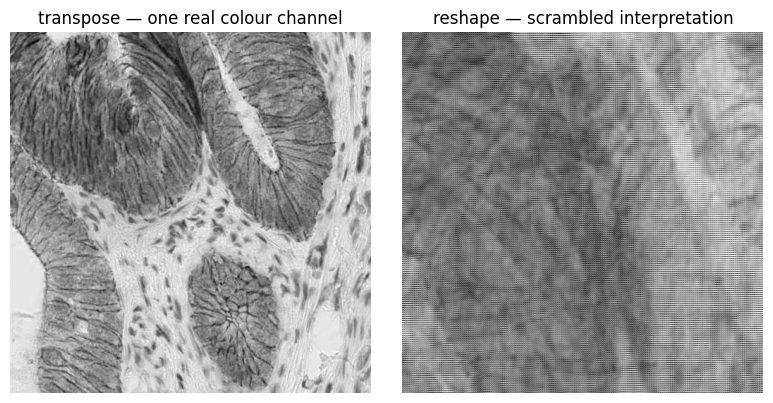

In [7]:
#@title Solution — try it yourself first { display-mode: 'form' }

chw = np.transpose(photo, (2, 0, 1))      # (3, 512, 512) — correct
wrong = photo.reshape(3, 512, 512)        # (3, 512, 512) — runs, but scrambles axes

print("same shape:", chw.shape == wrong.shape)       # True
print("same data arrangement:", np.array_equal(chw, wrong))  # False

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(chw[0], cmap="gray")
ax[0].set_title("transpose — one real colour channel")
ax[1].imshow(wrong[0], cmap="gray")
ax[1].set_title("reshape — scrambled interpretation")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()


## What just happened

You used real measured image values throughout the section:

1. a real histology image showed HWC → CHW;
2. three **distinct real RGB images** formed an NHWC batch and then an NCHW batch;
3. two axes both had size 3, proving that **shape alone does not record axis meaning**;
4. on the real histology image, `reshape` and `transpose` produced the same output shape but different data arrangements.

The central rule is:

> **Use `transpose`/axis-moving operations when axis meaning changes. Use `reshape` when you only want to reinterpret grouping without changing the intended axis order.**

These are the ideas to take into Kahoot 1.

> 🇪🇸 **Qué ocurrió:** trabajaste con valores reales de imágenes. Reordenaste HWC → CHW, construiste un lote real NHWC → NCHW y comprobaste que dos ejes pueden tener el mismo tamaño pero significados distintos. Finalmente viste que `reshape` puede producir la forma esperada y aun así desorganizar los datos. **Cuando cambia el significado o la posición de los ejes, usa una transposición o movimiento de ejes; no sustituyas esa operación por `reshape`.**

---

## Time for Kahoot 🎯

**Kahoot 1 — Tensor Vocabulary & Shapes** · 6 questions, about 5 minutes.

> 🇪🇸 **Vocabulario de tensores y formas** — 6 preguntas, unos 5 minutos.

Join at **kahoot.it** with the PIN on the facilitator's screen.

- [Quiz details and facilitator notes](https://project-delphi.github.io/tensors-workshop/kahoot.html#quiz-1)
- [Import file (`.xlsx`)](https://github.com/project-delphi/tensors-workshop/blob/main/kahoot/kahoot_quiz_1_vocabulary_shapes.xlsx)

Next up: **05 · Video pipeline design** — [open in Colab](https://colab.research.google.com/github/project-delphi/tensors-workshop/blob/main/notebooks/05-video-pipeline-design.ipynb).

[← Back to the workshop site](https://project-delphi.github.io/tensors-workshop/) · [All notebooks](https://project-delphi.github.io/tensors-workshop/notebooks.html) · [Handbook](https://project-delphi.github.io/tensors-workshop/tensors_workshop_plan_with_quizzes.html)